# Pesta Data 2026 - Notebook v6
Gabungan **main.ipynb (v5)** dan **eksp4.ipynb**, dengan dua ketentuan:

- **Fitur waktu TIDAK dipakai** (`discovered_week`, `discovered_hour_cat`, dan turunan tanggal `discovered` lainnya).
- **Perbaikan label TETAP dipakai** (`audit_mislabel` + `apply_relabel`), dan ditambah uji apakah perbaikan itu benar-benar membantu.

**Apa yang berubah dari v5:**

| Aspek | v5 (main.ipynb) | v6 (notebook ini) |
|---|---|---|
| Fitur | 17 fitur: `url_length`, `domain_age_days`, `brand_is_missing`, one-hot `sld` | Fitur bentuk URL, TF-IDF isi URL, `brand`, `registrar`, `sld`, `has_ip`, `confidence_level` |
| Model | Random Forest tunggal, tanpa tuning | Screening 3 kandidat, lalu tuning `RandomizedSearchCV` untuk 2 terbaik |
| Validasi | Split 80/20 + 5-Fold biasa, 7 kelas | `StratifiedGroupKFold` per `url` (tidak bocor), **9 kelas**, diulang 3 seed |
| Metrik | Macro-F1 semua kelas | Macro-F1 kelas yang ada di `y_true` (meniru aturan panitia) + macro-F1 kelas utama |
| Relabel | Ada | Tetap ada, plus uji dampaknya (bagian 10) |

## 1. Persiapan

In [1]:
import os
import re
import sys
import math
import warnings
from collections import Counter
from urllib.parse import urlparse, parse_qs, unquote

sys.path.insert(0, '../')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold, RandomizedSearchCV, cross_val_predict
from sklearn.metrics import f1_score, make_scorer, classification_report, confusion_matrix
from scipy.stats import loguniform

from audit_mislabel import audit_mislabel, apply_relabel, summarize_audit, summarize_diff

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 90)
sns.set_theme(style='whitegrid')

### 1.1 Konfigurasi

Semua pengaturan ada di satu tempat supaya gampang diubah untuk eksperimen.

- `USE_RELABEL`: perbaikan label. Sesuai permintaan, default `True`.
- `USE_DOMAIN_AGE`: `domain_age_days` dihitung dari `discovered - registration_date`, jadi masih bergantung pada tanggal `discovered`. Karena fitur waktu tidak dipakai, default `False`.
- `CONFIDENCE_VALID_MIN/MAX`: rentang wajar `confidence_level`. Di training ada 60 baris di luar 0-100 (-20, 250, 1000), sedangkan di predict tidak ada satu pun. Nilai di luar rentang ini dianggap tidak valid dan diisi median, bukan dibuang, supaya baris predict tidak hilang.
- `USE_MIDNIGHT_FEATURE`: `is_midnight_exact`, penanda baris yang tercatat persis jam 00:00. Ini bukan pengelompokan minggu/jam seperti eksp4, tapi penanda sumber data: 89% baris `spam` di training berjam 00:00, dibanding di bawah 3% kelas lain, dan proporsinya sama di predict. Default `True` karena polanya tersebar di semua bulan, bukan cuma satu batch.
- `USE_FAKESHOP_RULE`: aturan eksplisit untuk kelas `fakeshop` (bentuk URL polos + tanpa brand + tanggal dalam jendela 26 Apr - 1 Mei 2024). Default `False` karena ini murni hafalan dari 5 sampel, bukan pola yang bisa dijelaskan secara umum. Lihat catatan di bagian 5.


In [2]:
RANDOM_STATE = 42
VERSION = 'v6'

USE_RELABEL = True
RELABEL_THRESHOLD = 5
USE_DOMAIN_AGE = True
N_ITER_TUNING = 20

# --- konfigurasi baru ---
CONFIDENCE_VALID_MIN = 0
CONFIDENCE_VALID_MAX = 100
USE_MIDNIGHT_FEATURE = True     # is_midnight_exact: penanda sumber data (bukan pola minggu)
USE_FAKESHOP_RULE = False       # aturan sempit hasil hafalan 5 sampel fakeshop, lihat 1.2

RESULT_DIR = f'../../data/result/{VERSION}'
os.makedirs(RESULT_DIR, exist_ok=True)
np.random.seed(RANDOM_STATE)

## 2. Ambil Data

In [3]:
train = pd.read_csv('../../data/raw/training.csv')
test = pd.read_csv('../../data/raw/predict.csv')
submission_template = pd.read_csv('../../data/raw/submission-template.csv')

print(f"Dimensi Training : {train.shape}")
print(f"Dimensi Predict  : {test.shape}")
assert (test['id'].values == submission_template['id'].values).all(), 'Urutan id predict != template submission'
train.head(3)

Dimensi Training : (8400, 10)
Dimensi Predict  : (1500, 10)


,url,brand,discovered,confidence_level,ip,domain,sld,category,registrar,registration_date
0,https://lucah3.***********.my.id/,Telegram,5/1/2024 21:52,100,NaN,***********.my.id,my.id,phishingg,PT Web Media Technology Indonesia,5/14/2026
1,https://dpmptsp.*********.go.id/petapotensi/database/stores/?slot=slotnesia77,judi online,8/5/2024 20:41,100,103.162.68.84,*********.go.id,go.id,online gambling,Kementerian Komunikasi dan Informatika,5/11/2009
2,http://klikpad.bkpd.**************.go.id/klikpad/menu/home/SULTAN188/,-,6/14/2024 7:05,100,103.18.117.8,**************.go.id,go.id,online gambling,Kementerian Komunikasi dan Informatika,3/13/2008


## 3. Bersihkan Penulisan Category (TRAIN saja)
Hanya merapikan typo dan huruf besar/kecil. **Tidak ada penggabungan kategori**, semua 9 kelas resmi dipertahankan. Semua tulisan diubah ke huruf kecil dulu, lalu dipetakan. Kalau ada tulisan yang belum dikenal, kode berhenti dengan error supaya tidak ada label yang lolos diam-diam.

In [4]:
CATEGORY_MAP = {
    'online gambling': 'online gambling', 'online gamblingg': 'online gambling',
    'phishing': 'phishing', 'phishingg': 'phishing',
    'other': 'other', 'otherr': 'other',
    'spam': 'spam', 'spamm': 'spam',
    'malware': 'malware', 'malwaree': 'malware',
    'brand': 'brand',
    'fakeshop': 'fakeshop',
    'violence': 'violence',
    'piiexposure': 'piiexposure',
}
CANONICAL_CATEGORIES = sorted(set(CATEGORY_MAP.values()))


def normalize_category(x):
    key = str(x).strip().lower()
    if key not in CATEGORY_MAP:
        raise ValueError(f'Kategori tak dikenal: {x!r}')
    return CATEGORY_MAP[key]


train['category'] = train['category'].apply(normalize_category)

print(f'Jumlah kelas: {train["category"].nunique()} -> {CANONICAL_CATEGORIES}')
train['category'].value_counts()

Jumlah kelas: 9 -> ['brand', 'fakeshop', 'malware', 'online gambling', 'other', 'phishing', 'piiexposure', 'spam', 'violence']


category
online gambling    5447
phishing           2253
other               284
spam                185
malware             179
brand                45
fakeshop              5
violence              1
piiexposure           1
Name: count, dtype: int64

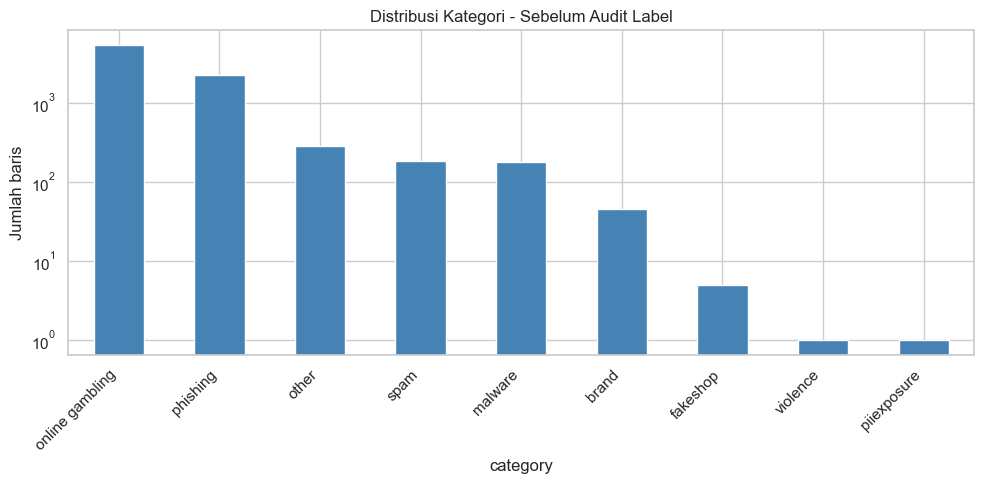

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
train['category'].value_counts().plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Distribusi Kategori - Sebelum Audit Label')
ax.set_ylabel('Jumlah baris')
ax.set_yscale('log')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 4. Audit & Perbaiki Category (TRAIN saja, bukti url + ip)
Sama seperti v5. Label sebelum perbaikan disimpan di kolom `category_asli`. Kolom itu **tidak dipakai sebagai fitur**, hanya untuk membandingkan dan menguji dampak relabel di bagian 10.

In [6]:
category_asli = train['category'].reset_index(drop=True).values
n_before = len(train)

if USE_RELABEL:
    train_audited = audit_mislabel(train)
    summarize_audit(train_audited)
    train, diff_table = apply_relabel(train_audited, score_threshold=RELABEL_THRESHOLD)
    summarize_diff(diff_table)
    diff_table.to_csv(f'{RESULT_DIR}/relabel_diff.csv', index=False)
    print(f"\nCatatan perubahan label tersimpan di {RESULT_DIR}/relabel_diff.csv")
else:
    diff_table = None
    print('USE_RELABEL = False -> label dipakai apa adanya (setelah dirapikan).')

train = train.reset_index(drop=True)
assert len(train) == n_before, 'apply_relabel mengubah jumlah baris, cek audit_mislabel'
assert set(train['category']) <= set(CANONICAL_CATEGORIES), 'Ada kategori di luar 9 kelas resmi setelah relabel'

train['category_asli'] = category_asli
n_changed = int((train['category'] != train['category_asli']).sum())
print(f'\nBaris yang labelnya berubah: {n_changed}')

pd.DataFrame({
    'sebelum_relabel': train['category_asli'].value_counts(),
    'sesudah_relabel': train['category'].value_counts(),
}).fillna(0).astype(int)

=== Distribusi skor kecurigaan ===
suspect_score
11       1
8       24
7        1
6        1
5       34
4       10
3      129
2      134
1      132
0     7934
Name: count, dtype: int64

Skor >=5 (relabel otomatis)      : 61 baris
Skor 3-4 (verifikasi manual)     : 139 baris
Skor 1-2 (biarkan, terlalu lemah): 266 baris
=== Total baris yang benar-benar berubah label: 61 ===

=== Perubahan per pasangan (label lama -> label baru) ===
category_before  category_after 
phishing         online gambling    20
malware          online gambling    14
spam             online gambling    12
other            online gambling     8
online gambling  phishing            6
spam             phishing            1
dtype: int64

Catatan perubahan label tersimpan di ../../data/result/v6/relabel_diff.csv

Baris yang labelnya berubah: 61


,sebelum_relabel,sesudah_relabel
online gambling,5447,5495
phishing,2253,2240
other,284,276
spam,185,172
malware,179,165
brand,45,45
fakeshop,5,5
violence,1,1
piiexposure,1,1


## 5. Feature Engineering (tanpa pengelompokan minggu/jam)

Fitur dibagi tiga kelompok:

1. **Bentuk URL** (numerik): panjang, kedalaman path, jumlah parameter, rasio angka, entropy karakter, ada tidaknya `https`, `www`, dan sebagainya.
2. **Isi URL** (teks): subdomain + path + query diubah menjadi TF-IDF kata dan TF-IDF karakter n-gram.
3. **Metadata** (kategori): `sld`, `brand`, `registrar`. Brand dan registrar yang jarang muncul dikelompokkan jadi satu kategori.

Yang **sengaja tidak dimasukkan**: `discovered_week`, `discovered_hour_cat`, `discovered_ord`, dan turunan tanggal lain seperti eksp4 pakai. Alasannya sudah dibahas: itu menangkap pola batch pengumpulan data, bukan ciri kelasnya.

**Dua fitur tambahan yang lebih tahan banting dari itu, keduanya opsional lewat konfigurasi:**

- `is_midnight_exact` (`USE_MIDNIGHT_FEATURE`): jam persis 00:00 menandai baris `spam` (89% vs <3% kelas lain di training), dan proporsinya sama di predict (2,8%). Ini penanda format sumber data, bukan pengelompokan minggu yang rapuh terhadap titik acuan.
- `fakeshop_rule_hit` (`USE_FAKESHOP_RULE`): kelima `fakeshop` di training semuanya berbentuk URL polos (`http://***.id`, tanpa path/query, tanpa brand) dan jatuh di tanggal 27-30 April 2024. Tidak ada fitur lain (registrar, sld, umur domain, IP) yang membedakan `fakeshop` dari kelas lain. Aturan ini murni menghafal jendela tanggal itu (+/- 1 hari margin) untuk baris berbentuk sama. Kalau `predict.csv` punya baris di jendela dan bentuk yang sama, aturan ini akan menembaknya sebagai `fakeshop`; kalau tidak ada, tidak berpengaruh. **Default mati** karena ini bukan pola yang bisa dijelaskan di luar 5 sampel itu, dan risikonya overfit ke training.


In [7]:
def is_bare(u):
    u2 = re.sub(r'^https?://', '', str(u)).rstrip('/')
    return '/' not in u2 and '?' not in u2


def shannon_entropy(s):
    if not s:
        return 0.0
    counts = Counter(s)
    n = len(s)
    return -sum((c / n) * math.log2(c / n) for c in counts.values())


def parse_url_parts(raw_url):
    u = str(raw_url)
    if '://' not in u:
        u = 'http://' + u
    try:
        return urlparse(u)
    except Exception:
        return urlparse('http://')


def mask_and_subdomain(domain):
    labels = str(domain).split('.')
    mask_idx = next((i for i, lab in enumerate(labels) if re.fullmatch(r'\*+', lab)), None)
    if mask_idx is None:
        return '', 0, str(domain)
    subdomain = '.'.join(labels[:mask_idx])
    mask_len = len(labels[mask_idx])
    tld_suffix = '.'.join(labels[mask_idx + 1:])
    return subdomain, mask_len, tld_suffix


def digit_ratio(s):
    s = s or ''
    return sum(ch.isdigit() for ch in s) / len(s) if len(s) > 0 else 0.0


def special_char_count(s):
    s = s or ''
    return sum(not ch.isalnum() for ch in s)

In [8]:
def engineer_features(df_in):
    df = df_in.copy()

    parsed = df['url'].apply(parse_url_parts)
    df['_path'] = parsed.apply(lambda p: unquote(p.path or ''))
    df['_query'] = parsed.apply(lambda p: unquote(p.query or ''))
    df['_path_query'] = (df['_path'] + ' ' + df['_query']).str.strip()

    mask_info = df['domain'].apply(mask_and_subdomain)
    df['subdomain_prefix'] = mask_info.apply(lambda t: t[0]).astype(object)
    df['mask_len'] = mask_info.apply(lambda t: t[1]).astype(float)

    # --- bentuk URL
    raw_url = df['url'].astype(str)
    df['url_length'] = raw_url.str.len()
    df['path_length'] = df['_path'].str.len()
    df['path_depth'] = df['_path'].str.count('/')
    df['query_param_count'] = df['_query'].apply(lambda q: len(parse_qs(q)) if q else 0)
    df['has_query'] = (df['_query'].str.len() > 0).astype(int)
    df['digit_ratio'] = df['_path_query'].apply(digit_ratio)
    df['special_char_count'] = df['_path_query'].apply(special_char_count)
    df['hyphen_count'] = df['_path_query'].str.count('-')
    df['path_query_entropy'] = df['_path_query'].apply(shannon_entropy)
    df['has_scheme'] = raw_url.str.contains('://').astype(float)
    df['is_https'] = raw_url.str.startswith('https').astype(float)
    df['trailing_slash'] = raw_url.str.endswith('/').astype(float)
    df['has_www'] = raw_url.str.contains(r'www\.').astype(float)
    df['n_sub_labels'] = df['subdomain_prefix'].apply(lambda s: len(s.split('.')) if s else 0).astype(float)
    df['is_bare'] = raw_url.apply(is_bare).astype(float)

    # --- metadata
    df['has_ip'] = df['ip'].notna().astype(int)

    # confidence_level: nilai di luar CONFIDENCE_VALID_MIN..MAX dianggap tidak valid
    # (di training ada -20, 250, 1000; tidak pernah muncul di predict). Diisi median
    # dari nilai yang valid, bukan dibuang, supaya baris predict tidak hilang.
    conf_raw = df['confidence_level'].astype(float)
    conf_valid_mask = conf_raw.between(CONFIDENCE_VALID_MIN, CONFIDENCE_VALID_MAX)
    df['confidence_is_outlier'] = (~conf_valid_mask).astype(float)
    conf_median = conf_raw.where(conf_valid_mask).median()
    df['confidence_level'] = conf_raw.where(conf_valid_mask, conf_median)

    df['sld_clean'] = df['sld'].fillna('unknown').astype(object)

    # --- teks untuk TF-IDF (tanda *** dari masking dibuang)
    text_raw = df['subdomain_prefix'].astype(str) + ' ' + df['_path_query'].astype(str)
    text_raw = text_raw.str.replace(r'\*+', ' ', regex=True)
    df['url_text'] = text_raw.str.lower().str.strip().astype(object)

    # --- opsional: is_midnight_exact, penanda sumber data (bukan pengelompokan minggu/jam)
    if USE_MIDNIGHT_FEATURE:
        discovered_dt = pd.to_datetime(df['discovered'], format='%m/%d/%Y %H:%M', errors='coerce')
        df['is_midnight_exact'] = (
            (discovered_dt.dt.hour == 0) & (discovered_dt.dt.minute == 0)
        ).astype(float)

    # --- opsional: aturan sempit khusus fakeshop (hafalan dari 5 sampel, lihat bagian 5)
    if USE_FAKESHOP_RULE:
        discovered_dt = pd.to_datetime(df['discovered'], format='%m/%d/%Y %H:%M', errors='coerce')
        fakeshop_window = discovered_dt.between('2024-04-26', '2024-05-01 23:59:59')
        is_form = (
            df['is_bare'].astype(bool)
            & ~raw_url.str.startswith('https')
            & (df['brand'].isna() | df['brand'].astype(str).str.strip().eq('-'))
        )
        df['fakeshop_rule_hit'] = (fakeshop_window & is_form).astype(float)

    # --- opsional: umur domain (turunan tanggal discovered, default mati)
    if USE_DOMAIN_AGE:
        discovered_dt = pd.to_datetime(df['discovered'], format='%m/%d/%Y %H:%M', errors='coerce')
        reg_dt = pd.to_datetime(df['registration_date'], format='%m/%d/%Y', errors='coerce')
        df['domain_age_days'] = (discovered_dt - reg_dt).dt.days.astype(float)
        df['domain_age_is_negative'] = (df['domain_age_days'] < 0).astype(float)

    return df


NUMERIC_FEATURES = [
    'url_length', 'path_length', 'path_depth', 'query_param_count', 'has_query',
    'digit_ratio', 'special_char_count', 'hyphen_count', 'path_query_entropy',
    'mask_len', 'has_ip', 'confidence_level', 'confidence_is_outlier',
    'has_scheme', 'is_https', 'trailing_slash', 'has_www', 'n_sub_labels', 'is_bare',
]
if USE_MIDNIGHT_FEATURE:
    NUMERIC_FEATURES += ['is_midnight_exact']
if USE_FAKESHOP_RULE:
    NUMERIC_FEATURES += ['fakeshop_rule_hit']
if USE_DOMAIN_AGE:
    NUMERIC_FEATURES += ['domain_age_days', 'domain_age_is_negative']

CATEGORICAL_FEATURES = ['sld_clean', 'brand_clean', 'registrar_clean']
TEXT_FEATURE = 'url_text'

### 5.1 Jalankan ke train dan predict, lalu kelompokkan brand/registrar yang jarang

Frekuensi dihitung **hanya dari data train**, lalu dipakai apa adanya ke data predict.

In [9]:
def clean_brand_series(s):
    s = s.fillna('unknown').astype(str).str.strip().str.lower()
    return s.replace({'-': 'unknown'})


def clean_registrar_series(s):
    return s.fillna('unknown').astype(str).str.strip().str.lower()


def build_keep_set(series, min_count):
    counts = series.value_counts()
    return set(counts[counts >= min_count].index)


def apply_bucket(series, keep_set, bucket_name):
    return series.where(series.isin(keep_set), bucket_name).astype(object)


train_feat = engineer_features(train)
predict_feat = engineer_features(test)

brand_train = clean_brand_series(train_feat['brand'])
registrar_train = clean_registrar_series(train_feat['registrar'])
brand_keep = build_keep_set(brand_train, min_count=5)
registrar_keep = build_keep_set(registrar_train, min_count=10)

train_feat['brand_clean'] = apply_bucket(brand_train, brand_keep, 'rare_brand')
train_feat['registrar_clean'] = apply_bucket(registrar_train, registrar_keep, 'other_registrar')
predict_feat['brand_clean'] = apply_bucket(clean_brand_series(predict_feat['brand']), brand_keep, 'rare_brand')
predict_feat['registrar_clean'] = apply_bucket(clean_registrar_series(predict_feat['registrar']), registrar_keep, 'other_registrar')

used_cols = NUMERIC_FEATURES + CATEGORICAL_FEATURES + [TEXT_FEATURE]
assert not any(c.startswith('discovered') for c in used_cols), 'Ada fitur waktu yang ikut terpakai'

print(f'Fitur numerik: {len(NUMERIC_FEATURES)} | kategorikal: {len(CATEGORICAL_FEATURES)} | teks: 1')
print('Fitur waktu (discovered_*) dipakai: TIDAK')
train_feat[used_cols].head()

Fitur numerik: 22 | kategorikal: 3 | teks: 1
Fitur waktu (discovered_*) dipakai: TIDAK


,url_length,path_length,path_depth,query_param_count,has_query,digit_ratio,special_char_count,hyphen_count,path_query_entropy,mask_len,has_ip,confidence_level,confidence_is_outlier,has_scheme,is_https,trailing_slash,has_www,n_sub_labels,is_bare,is_midnight_exact,domain_age_days,domain_age_is_negative,sld_clean,brand_clean,registrar_clean,url_text
0,33,1,1,0,0,0.000000,1,0,-0.000000,11.0,0,100.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,-743.0,1.0,my.id,telegram,pt web media technology indonesia,/
1,77,29,4,1,1,0.043478,6,0,3.689202,9.0,1,100.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,5565.0,0.0,go.id,judi online,kementerian komunikasi dan informatika,/petapotensi/database/stores/ slot=slotnesia77
2,69,29,5,0,0,0.103448,5,0,4.181786,14.0,1,100.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,5937.0,0.0,go.id,unknown,kementerian komunikasi dan informatika,/klikpad/menu/home/sultan188/
3,76,12,3,1,1,0.038462,5,0,3.950064,20.0,1,100.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,5486.0,0.0,go.id,unknown,kementerian komunikasi dan informatika,/public/svg/ google=toko4d
4,94,22,4,1,1,0.000000,12,1,4.660022,10.0,1,100.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,4587.0,0.0,go.id,unknown,kementerian komunikasi dan informatika,/e-koor/storage/nenen/ listing=slot+gacor+hari+ini+dan+polanya


## 6. Membagi Data Latih dan Validasi

Semua 9 kelas ikut, termasuk `violence` dan `piiexposure` yang hanya 1 sampel. Pembagian memakai `StratifiedGroupKFold` dengan `url` sebagai group, jadi URL yang sama tidak mungkin muncul di train dan validasi sekaligus. Satu fold (20%) jadi hold-out, sisanya untuk screening dan tuning.

**Macro-F1 yang dipakai** meniru aturan panitia: rata-rata hanya dari kelas yang benar-benar ada di `y_true`. Kalau suatu fold tidak punya contoh `fakeshop`, kelas itu tidak dihitung di fold tersebut. Tapi kalau ada dan salah diprediksi, skornya 0 dan menurunkan rata-rata.

`MAIN_LABELS` (kelas dengan minimal 20 contoh) ditampilkan sebagai pembanding tambahan, karena satu contoh `fakeshop`, `violence`, atau `piiexposure` bisa menggeser skor semua-kelas cukup jauh.

In [10]:
X_cv = train_feat.reset_index(drop=True)
y_cv = X_cv['category']
groups_cv = X_cv['url'].values

class_counts = y_cv.value_counts()
MAIN_LABELS = sorted(c for c in class_counts.index if class_counts[c] >= 20)

group_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
train_idx, val_idx = next(group_cv.split(X_cv, y_cv, groups_cv))
X_train, X_val = X_cv.iloc[train_idx], X_cv.iloc[val_idx]
y_train, y_val = y_cv.iloc[train_idx], y_cv.iloc[val_idx]
groups_train = X_train['url'].values
val_labels = sorted(y_val.unique())


def macro_f1_present(y_true, y_pred):
    labels = sorted(set(y_true))
    return f1_score(y_true, y_pred, labels=labels, average='macro', zero_division=0)


def macro_f1_main(y_true, y_pred):
    return f1_score(y_true, y_pred, labels=MAIN_LABELS, average='macro', zero_division=0)


def per_class_f1(y_true, y_pred, labels):
    scores = f1_score(y_true, y_pred, labels=labels, average=None, zero_division=0)
    return dict(zip(labels, scores))


present_scorer = make_scorer(macro_f1_present)

train_counts = y_train.value_counts()
balanced_weights = len(y_train) / (len(train_counts) * train_counts)
soft_weights = np.sqrt(balanced_weights).to_dict()

print('X_train:', X_train.shape, '| X_val:', X_val.shape)
print('Kelas utama (>=20 contoh):', MAIN_LABELS)
print('Kelas di X_val:', val_labels)
print('URL yang sama di train dan val:', len(set(X_train['url']) & set(X_val['url'])))
class_counts

c:\syntax\Codelab\Aptikom-Pedas2026\venv\lib\site-packages\sklearn\model_selection\_split.py:1035: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


X_train: (6674, 56) | X_val: (1726, 56)
Kelas utama (>=20 contoh): ['brand', 'malware', 'online gambling', 'other', 'phishing', 'spam']
Kelas di X_val: ['brand', 'fakeshop', 'malware', 'online gambling', 'other', 'phishing', 'spam']
URL yang sama di train dan val: 0


category
online gambling    5495
phishing           2240
other               276
spam                172
malware             165
brand                45
fakeshop              5
violence              1
piiexposure           1
Name: count, dtype: int64

## 7. Screening Model Kandidat

Tiga kandidat: Logistic Regression dan Linear SVC (linear, cocok untuk teks TF-IDF yang sparse), serta Random Forest (berbasis pohon). Preprocessor sama untuk semuanya, yang beda hanya classifier di ujung pipeline.

Fitur numerik diproses dengan median imputer, `RobustScaler`, lalu `clip` ke rentang -5 sampai 5 supaya nilai ekstrem (misalnya `confidence_level`) tidak mengganggu model linear.

In [11]:
def clip_scaled(X):
    return np.clip(X, -5, 5)


def build_preprocessor():
    return ColumnTransformer(
        transformers=[
            ('tfidf_word', TfidfVectorizer(
                analyzer='word', ngram_range=(1, 2), min_df=2, max_features=3000,
                sublinear_tf=True), TEXT_FEATURE),
            ('tfidf_char', TfidfVectorizer(
                analyzer='char_wb', ngram_range=(3, 5), min_df=2, max_features=3000,
                sublinear_tf=True), TEXT_FEATURE),
            ('cat', OneHotEncoder(handle_unknown='ignore'), CATEGORICAL_FEATURES),
            ('num', Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', RobustScaler()),
                ('clip', FunctionTransformer(clip_scaled)),
            ]), NUMERIC_FEATURES),
        ],
        sparse_threshold=0.3,
    )


def build_pipeline(clf):
    return Pipeline([('features', build_preprocessor()), ('clf', clf)])


CANDIDATE_MODELS = {
    'logistic_regression': lambda: LogisticRegression(
        max_iter=3000, class_weight='balanced', random_state=RANDOM_STATE),
    'linear_svc': lambda: LinearSVC(
        class_weight='balanced', random_state=RANDOM_STATE, max_iter=5000),
    'random_forest': lambda: RandomForestClassifier(
        n_estimators=300, class_weight='balanced_subsample', random_state=RANDOM_STATE, n_jobs=-1),
}

In [12]:
screening_results = []
for name, factory in CANDIDATE_MODELS.items():
    pipe = build_pipeline(factory())
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_val)
    row = {
        'model': name,
        'macro_f1_main': macro_f1_main(y_val, pred),
        'macro_f1_val': macro_f1_present(y_val, pred),
    }
    row.update(per_class_f1(y_val, pred, ['malware', 'spam', 'brand']))
    row['fakeshop_hit'] = int(((y_val == 'fakeshop').values & (pred == 'fakeshop')).sum())
    screening_results.append(row)

screening_df = pd.DataFrame(screening_results).sort_values('macro_f1_val', ascending=False)
screening_df

,model,macro_f1_main,macro_f1_val,malware,spam,brand,fakeshop_hit
1,linear_svc,0.875706,0.750605,0.881356,0.914286,0.545455,0
0,logistic_regression,0.849010,0.727723,0.861538,0.901408,0.434783,0
2,random_forest,0.842300,0.721971,0.821429,0.882353,0.444444,0


Dua kandidat dengan `macro_f1_val` tertinggi dibawa ke tuning. Kalau urutan `macro_f1_val` dan `macro_f1_main` berbeda jauh, kemungkinan besar penyebabnya satu contoh `fakeshop`, bukan perbedaan kualitas model sebenarnya.

In [13]:
TOP_N_CANDIDATES = 2
top_candidates = screening_df['model'].head(TOP_N_CANDIDATES).tolist()
top_candidates

['linear_svc', 'logistic_regression']

## 8. Hyperparameter Tuning (RandomizedSearchCV)

Hyperparameter adalah pengaturan model yang ditentukan **sebelum** training (misalnya `C`, `class_weight`, `max_features` TF-IDF). `RandomizedSearchCV` mengambil `N_ITER_TUNING` kombinasi acak dari rentang di bawah, menilai tiap kombinasi dengan 5-fold group CV memakai macro-F1, lalu melatih ulang model dengan kombinasi terbaik.

`class_weight` ikut dicari. Selain `balanced` dan `None`, ada `soft_weights` (akar dari bobot balanced) karena bobot balanced penuh bisa membuat model terlalu sering menebak kelas kecil.

Tuning hanya memakai `X_train`; `X_val` tidak tersentuh, jadi tetap jadi hold-out yang jujur.

In [14]:
tuning_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

PARAM_DISTRIBUTIONS = {
    'logistic_regression': {
        'clf__C': loguniform(1e-2, 1e2),
        'clf__class_weight': ['balanced', None, soft_weights],
        'features__tfidf_word__max_features': [1000, 2000, 3000, 5000],
        'features__tfidf_word__min_df': [1, 2, 3],
        'features__tfidf_char__max_features': [1000, 2000, 3000, 5000],
    },
    'linear_svc': {
        'clf__C': loguniform(1e-2, 1e2),
        'clf__loss': ['hinge', 'squared_hinge'],
        'clf__class_weight': ['balanced', None, soft_weights],
        'features__tfidf_word__max_features': [1000, 2000, 3000, 5000],
        'features__tfidf_word__min_df': [1, 2, 3],
        'features__tfidf_char__max_features': [1000, 2000, 3000, 5000],
    },
    'random_forest': {
        'clf__n_estimators': [200, 300, 500],
        'clf__max_depth': [None, 20, 40, 60],
        'clf__min_samples_leaf': [1, 2, 4],
        'clf__max_features': ['sqrt', 'log2'],
        'clf__class_weight': ['balanced_subsample', 'balanced', None, soft_weights],
        'features__tfidf_word__max_features': [1000, 2000, 3000],
        'features__tfidf_char__max_features': [1000, 2000, 3000],
    },
}

In [15]:
tuned_searches = {}
for name in top_candidates:
    print(f'Tuning {name}...')
    search = RandomizedSearchCV(
        build_pipeline(CANDIDATE_MODELS[name]()),
        param_distributions=PARAM_DISTRIBUTIONS[name],
        n_iter=N_ITER_TUNING,
        scoring=present_scorer,
        cv=tuning_cv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        refit=True,
    )
    search.fit(X_train, y_train, groups=groups_train)
    tuned_searches[name] = search
    print(f'  macro-F1 CV terbaik: {search.best_score_:.4f}')

Tuning linear_svc...


c:\syntax\Codelab\Aptikom-Pedas2026\venv\lib\site-packages\sklearn\model_selection\_split.py:1035: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\syntax\Codelab\Aptikom-Pedas2026\venv\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\syntax\Codelab\Aptikom-Pedas2026\venv\lib\site-packages\sklearn\model_selection\_split.py:1035: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


  macro-F1 CV terbaik: 0.7817
Tuning logistic_regression...
  macro-F1 CV terbaik: 0.7630


### 8.1 Memilih model final

Pemilihan memakai prediksi out-of-fold (OOF) di `X_train`, diurutkan berdasarkan macro-F1 semua kelas. Hasil `fakeshop` (TP, FP, FN) ditampilkan di sebelahnya supaya kelihatan kalau urutan ditentukan oleh kelas yang sangat kecil itu.

In [16]:
selection_rows = []
for name in top_candidates:
    tuned_estimator = clone(tuned_searches[name].best_estimator_)
    sel_pred = cross_val_predict(
        tuned_estimator, X_train, y_train, cv=tuning_cv, groups=groups_train, n_jobs=-1)
    fs_true = (y_train == 'fakeshop').values
    fs_pred = sel_pred == 'fakeshop'
    row = {
        'model': name,
        'cv_tuning_semua_kelas': tuned_searches[name].best_score_,
        'oof_macro_semua_kelas': macro_f1_present(y_train, sel_pred),
        'oof_macro_kelas_utama': macro_f1_main(y_train, sel_pred),
    }
    row.update(per_class_f1(y_train, sel_pred, ['malware', 'spam', 'brand']))
    row['fakeshop_TP'] = int((fs_true & fs_pred).sum())
    row['fakeshop_FP'] = int((~fs_true & fs_pred).sum())
    row['fakeshop_FN'] = int((fs_true & ~fs_pred).sum())
    selection_rows.append(row)

comparison_df = pd.DataFrame(selection_rows).sort_values('oof_macro_semua_kelas', ascending=False)
display(comparison_df)

final_model_name = comparison_df.iloc[0]['model']
final_search = tuned_searches[final_model_name]
print('Model final yang dipilih:', final_model_name)
final_search.best_params_

c:\syntax\Codelab\Aptikom-Pedas2026\venv\lib\site-packages\sklearn\model_selection\_split.py:1035: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\syntax\Codelab\Aptikom-Pedas2026\venv\lib\site-packages\sklearn\model_selection\_split.py:1035: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


,model,cv_tuning_semua_kelas,oof_macro_semua_kelas,oof_macro_kelas_utama,malware,spam,brand,fakeshop_TP,fakeshop_FP,fakeshop_FN
0,linear_svc,0.781705,0.627985,0.900311,0.83871,0.893617,0.805556,1,3,3
1,logistic_regression,0.762984,0.614320,0.891177,0.80000,0.913669,0.788732,1,6,3


Model final yang dipilih: linear_svc


{'clf__C': np.float64(1.8655260217376837),
 'clf__class_weight': 'balanced',
 'clf__loss': 'hinge',
 'features__tfidf_char__max_features': 2000,
 'features__tfidf_word__max_features': 2000,
 'features__tfidf_word__min_df': 2}

## 9. Evaluasi Model Final

### 9.1 Hold-out (X_val)

In [17]:
best_pipeline = build_pipeline(CANDIDATE_MODELS[final_model_name]())
best_pipeline.set_params(**final_search.best_params_)
best_pipeline.fit(X_train, y_train)

y_val_pred = best_pipeline.predict(X_val)
print(f'Macro-F1 di X_val (kelas yang ada di y_true): {macro_f1_present(y_val, y_val_pred):.4f}')
print(f'Macro-F1 kelas utama                        : {macro_f1_main(y_val, y_val_pred):.4f}')
print()
print(classification_report(y_val, y_val_pred, labels=val_labels, zero_division=0))

Macro-F1 di X_val (kelas yang ada di y_true): 0.7186
Macro-F1 kelas utama                        : 0.8384

                 precision    recall  f1-score   support

          brand       0.60      0.27      0.38        11
       fakeshop       0.00      0.00      0.00         1
        malware       0.81      0.87      0.84        30
online gambling       0.99      0.99      0.99      1072
          other       0.91      0.98      0.94       119
       phishing       0.99      0.97      0.98       458
           spam       0.89      0.91      0.90        35

       accuracy                           0.98      1726
      macro avg       0.74      0.71      0.72      1726
   weighted avg       0.98      0.98      0.98      1726



c:\syntax\Codelab\Aptikom-Pedas2026\venv\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


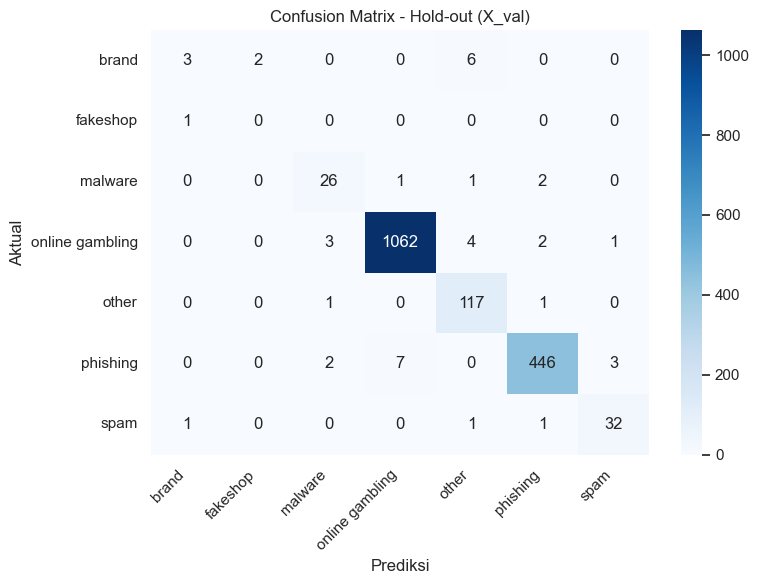

In [18]:
cm = confusion_matrix(y_val, y_val_pred, labels=val_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=val_labels, yticklabels=val_labels)
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix - Hold-out (X_val)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 9.2 Group Cross Validation (seluruh data)

Prediksi out-of-fold dari semua fold digabung, lalu classification report gabungan dipakai sebagai angka utama. Rata-rata per fold tercampur dua artefak: fold yang memegang `violence` atau `piiexposure` pasti bernilai 0 untuk kelas itu, dan `fakeshop` yang hanya 5 contoh membuat skor naik turun.

In [19]:
final_pipeline_template = build_pipeline(CANDIDATE_MODELS[final_model_name]())
final_pipeline_template.set_params(**final_search.best_params_)

oof_pred = cross_val_predict(
    final_pipeline_template, X_cv, y_cv, cv=group_cv, groups=groups_cv, n_jobs=-1)

print(f'Macro-F1 OOF kelas utama : {macro_f1_main(y_cv, oof_pred):.4f}')
print(f'Macro-F1 OOF semua kelas : {macro_f1_present(y_cv, oof_pred):.4f}')
print()
print(classification_report(y_cv, oof_pred, zero_division=0))

c:\syntax\Codelab\Aptikom-Pedas2026\venv\lib\site-packages\sklearn\model_selection\_split.py:1035: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Macro-F1 OOF kelas utama : 0.8805
Macro-F1 OOF semua kelas : 0.5870

                 precision    recall  f1-score   support

          brand       0.72      0.64      0.68        45
       fakeshop       0.00      0.00      0.00         5
        malware       0.81      0.85      0.83       165
online gambling       0.99      0.99      0.99      5495
          other       0.90      0.94      0.92       276
       phishing       0.98      0.97      0.97      2240
    piiexposure       0.00      0.00      0.00         1
           spam       0.85      0.92      0.88       172
       violence       0.00      0.00      0.00         1

       accuracy                           0.97      8400
      macro avg       0.58      0.59      0.59      8400
   weighted avg       0.98      0.97      0.98      8400



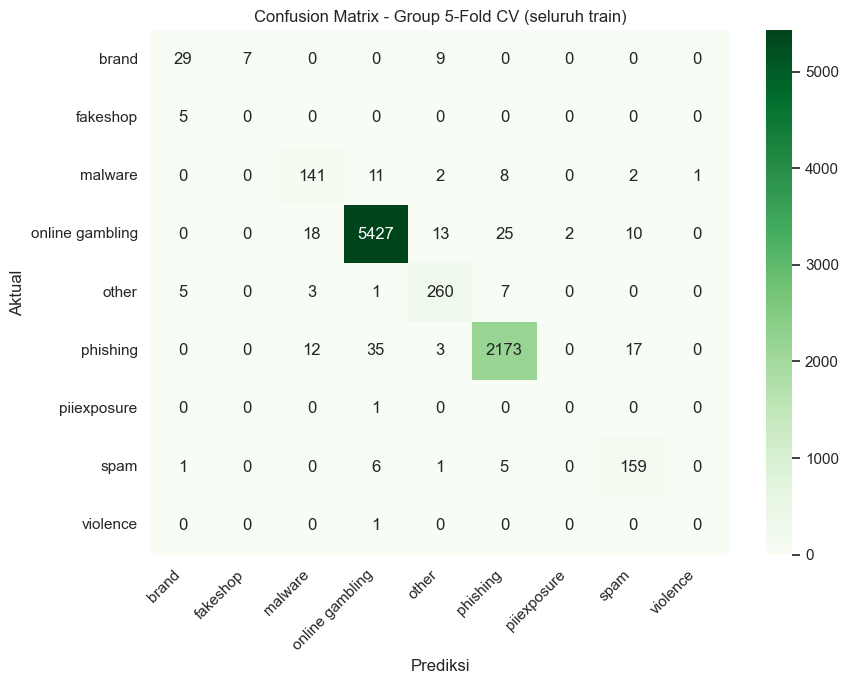

In [20]:
labels_cv = sorted(y_cv.unique())
cm_cv = confusion_matrix(y_cv, oof_pred, labels=labels_cv)
plt.figure(figsize=(9, 7))
sns.heatmap(cm_cv, annot=True, fmt='d', cmap='Greens', xticklabels=labels_cv, yticklabels=labels_cv)
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix - Group 5-Fold CV (seluruh train)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 9.3 Repeated group CV (3 seed)

Satu seed bisa kebetulan bagus atau jelek. Standar deviasi antar seed menunjukkan seberapa besar noise dari cara membagi fold. Ekspektasi yang wajar: `std` kecil untuk kelas besar, dan besar untuk `fakeshop`.

In [21]:
repeat_rows = []
for seed in [42, 43, 44]:
    seed_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)
    seed_pred = cross_val_predict(
        final_pipeline_template, X_cv, y_cv, cv=seed_cv, groups=groups_cv, n_jobs=-1)
    row = {
        'seed': seed,
        'macro_f1_kelas_utama': macro_f1_main(y_cv, seed_pred),
        'macro_f1_semua_kelas': macro_f1_present(y_cv, seed_pred),
    }
    row.update(per_class_f1(y_cv, seed_pred, ['malware', 'spam', 'brand', 'other', 'fakeshop']))
    repeat_rows.append(row)

repeat_df = pd.DataFrame(repeat_rows)
display(repeat_df.round(4))
repeat_df.drop(columns='seed').agg(['mean', 'std']).round(4)

c:\syntax\Codelab\Aptikom-Pedas2026\venv\lib\site-packages\sklearn\model_selection\_split.py:1035: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\syntax\Codelab\Aptikom-Pedas2026\venv\lib\site-packages\sklearn\model_selection\_split.py:1035: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\syntax\Codelab\Aptikom-Pedas2026\venv\lib\site-packages\sklearn\model_selection\_split.py:1035: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


,seed,macro_f1_kelas_utama,macro_f1_semua_kelas,malware,spam,brand,other,fakeshop
0,42,0.8805,0.5870,0.8319,0.8833,0.6824,0.9220,0.0000
1,43,0.8881,0.6106,0.8353,0.8977,0.7111,0.9217,0.1667
2,44,0.8909,0.5939,0.8452,0.8858,0.7234,0.9281,0.0000


,macro_f1_kelas_utama,macro_f1_semua_kelas,malware,spam,brand,other,fakeshop
mean,0.8865,0.5972,0.8375,0.8890,0.7056,0.9239,0.0556
std,0.0053,0.0121,0.0069,0.0077,0.0211,0.0036,0.0962


### 9.4 Analisis error

Kolom `url_konflik` menandai URL yang muncul dengan label berbeda di data. Error di situ sulit dihindari oleh model apa pun, dan bisa jadi kandidat untuk diperiksa manual (mungkin noise label yang belum tertangkap `audit_mislabel`).

In [22]:
error_df = X_cv[['url', 'brand', 'registrar_clean']].assign(aktual=y_cv.values, prediksi=oof_pred)
error_df = error_df[error_df['aktual'] != error_df['prediksi']]

labels_per_url = X_cv.assign(aktual=y_cv.values).groupby('url')['aktual'].transform('nunique')
error_df['url_konflik'] = labels_per_url.loc[error_df.index] > 1

print('Total error:', len(error_df), '| di URL dengan label konflik:', int(error_df['url_konflik'].sum()))
error_df.groupby(['aktual', 'prediksi']).size().sort_values(ascending=False).head(10)

Total error: 211 | di URL dengan label konflik: 77


aktual           prediksi       
phishing         online gambling    35
online gambling  phishing           25
                 malware            18
phishing         spam               17
online gambling  other              13
phishing         malware            12
malware          online gambling    11
online gambling  spam               10
brand            other               9
malware          phishing            8
dtype: int64

In [23]:
top_pairs = (error_df.groupby(['aktual', 'prediksi']).size()
             .sort_values(ascending=False).head(3).index.tolist())
for aktual, prediksi in top_pairs:
    subset = error_df[(error_df['aktual'] == aktual) & (error_df['prediksi'] == prediksi)]
    print(f'{aktual} diprediksi {prediksi}: {len(subset)} kasus')
    display(subset[['url', 'brand', 'url_konflik']].head(10))

phishing diprediksi online gambling: 35 kasus


,url,brand,url_konflik
21,https://***.id/m/Gq13ta?=https&apps_bmo=,NaN,False
80,https://satbrimob.kalbar.*****.go.id/,-,False
930,https://dana-id-customer-claim-uang-tunai.***.my.id/,NaN,False
1024,https://********.id/,NaN,True
1120,http://tdffi.***********.ac.id/,NaN,False
1157,https://**********.id/css/main/v2/swiper/swiper-master/src/modules/support/glossary/?%...,NaN,False
1556,https://id.***********.go.id/tentang-pengadilan/,judi online,True
1573,https://*******.id/bnkofamerica,NaN,False
1625,https://geoportal.**********.go.id/situstoto/,-,False
2153,http://wells.**********.id/,NaN,False


online gambling diprediksi phishing: 25 kasus


,url,brand,url_konflik
299,https://******.id/Rupiah126,-,False
618,https://bpo.******.id/?ganteng=bgibola,-,False
1361,https://sps.***.ac.id/gibran/index.html,-,False
1461,https://igracias.************.ac.id/amp/KIJANGWIN/KIJANGWIN.html,-,False
1475,https://ppdb.**************.sch.id/.well-known/-/?prince=slot+hoki+777,-,False
1843,https://***********.id/games/idntrade,-,False
2724,https://teswebkuu.****.my.id/go.php,Other,True
3381,https://**************.id/.well-known/shopify/monorail/unstable/produce_batch,judi online,False
3611,https://ejournal.*******.ac.id/ejournal/wp-site/?produk=RTP+RAJABANDOT+LOGIN,stmikku.ac.id,False
3659,https://********.id/angkasa168/index.html,-,False


online gambling diprediksi malware: 18 kasus


,url,brand,url_konflik
311,https://lms.*****.co.id/jz/,-,False
531,http://***********.sch.id/new/public/ckfinder/userfiles/files,NaN,True
632,http://perpus.***********.ac.id/files/indo/,-,False
887,https://spada.**************.sch.id/,-,False
963,https://katalog.*****.co.id/,-,False
1133,https://lms.*****.co.id/jz/,-,False
1176,*****.id,-,True
1500,https://********.or.id/wp-includes/css/dist/777/,-,False
1817,site:sibkd.*******.ac.id,-,False
3259,https://***********.co.id/2022/05/pragmatic88-login-dewa89,-,False


## 10. Uji Dampak Perbaikan Label

Perbaikan label mengubah data latih **dan** data yang dipakai untuk menilai, jadi skor "sebelum vs sesudah relabel" tidak bisa dibandingkan begitu saja. Cara yang lebih adil:

- **Versi A**: model dilatih dengan label **asli** (`category_asli`).
- **Versi B**: model dilatih dengan label **hasil relabel** (`category`).
- Kedua versi memakai fold yang **persis sama**, dan dinilai **hanya pada baris yang labelnya tidak berubah**, sehingga tolok ukurnya sama untuk keduanya.

Kalau B lebih tinggi atau sama dengan A, relabel membantu. Kalau B lebih rendah, pertimbangkan `USE_RELABEL = False` atau naikkan `RELABEL_THRESHOLD`. Keterbatasan: uji ini tidak bisa menilai baris yang berubah itu sendiri, karena kita tidak punya label kebenaran untuk baris tersebut.

In [24]:
unchanged = (train['category'] == train['category_asli']).values
y_asli = train['category_asli'].reset_index(drop=True)

if n_changed == 0:
    print('Tidak ada label yang berubah, uji dampak relabel dilewati.')
else:
    ablation_rows = []
    for seed in [42, 43, 44]:
        # fold dibuat dari label hasil relabel, lalu dipakai ulang untuk kedua versi
        folds = list(StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)
                     .split(X_cv, y_cv, groups_cv))
        for versi, y_latih in [('A: label asli', y_asli), ('B: label relabel', y_cv)]:
            pred = cross_val_predict(
                final_pipeline_template, X_cv, y_latih, cv=folds, n_jobs=-1)
            yt, yp = y_cv[unchanged], pred[unchanged]
            ablation_rows.append({
                'seed': seed, 'versi': versi,
                'macro_f1_kelas_utama': macro_f1_main(yt, yp),
                'macro_f1_semua_kelas': macro_f1_present(yt, yp),
            })
    ablation_df = pd.DataFrame(ablation_rows)
    display(ablation_df.round(4))
    print(f'Dinilai pada {int(unchanged.sum())} baris yang labelnya tidak berubah (dari {len(unchanged)}).')
    ablation_df.groupby('versi')[['macro_f1_kelas_utama', 'macro_f1_semua_kelas']].agg(['mean', 'std']).round(4)

c:\syntax\Codelab\Aptikom-Pedas2026\venv\lib\site-packages\sklearn\model_selection\_split.py:1035: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\syntax\Codelab\Aptikom-Pedas2026\venv\lib\site-packages\sklearn\model_selection\_split.py:1035: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\syntax\Codelab\Aptikom-Pedas2026\venv\lib\site-packages\sklearn\model_selection\_split.py:1035: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


,seed,versi,macro_f1_kelas_utama,macro_f1_semua_kelas
0,42,A: label asli,0.8866,0.5911
1,42,B: label relabel,0.8823,0.5882
2,43,A: label asli,0.8868,0.6071
3,43,B: label relabel,0.8899,0.6118
4,44,A: label asli,0.8939,0.6118
5,44,B: label relabel,0.8926,0.5951


Dinilai pada 8339 baris yang labelnya tidak berubah (dari 8400).


## 11. Retrain Pakai SELURUH Train, Prediksi ke Predict.csv

**PENTING**: jatah submission maksimal 3x (sesuai juknis), jadi pastikan hasil validasi di atas sudah memuaskan sebelum submit. Model dilatih ulang dengan hyperparameter terbaik memakai seluruh data training (label hasil relabel).

In [25]:
production_pipeline = build_pipeline(CANDIDATE_MODELS[final_model_name]())
production_pipeline.set_params(**final_search.best_params_)
production_pipeline.fit(train_feat, train_feat['category'])

predict_pred = production_pipeline.predict(predict_feat)

expected_counts = (y_cv.value_counts(normalize=True) * len(predict_feat)).round(1)
pd.DataFrame({
    'prediksi': pd.Series(predict_pred).value_counts(),
    'perkiraan_dari_proporsi_training': expected_counts,
}).fillna(0)

c:\syntax\Codelab\Aptikom-Pedas2026\venv\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


,prediksi,perkiraan_dari_proporsi_training
brand,9.0,8.0
fakeshop,2.0,0.9
malware,35.0,29.5
online gambling,985.0,981.2
other,47.0,49.3
phishing,385.0,400.0
piiexposure,0.0,0.2
spam,37.0,30.7
violence,0.0,0.2


## 12. Simpan Submission

In [26]:
submission = pd.DataFrame({'id': test['id'], 'category': predict_pred})

assert len(submission) == len(submission_template)
assert (submission['id'].values == submission_template['id'].values).all()
assert submission['category'].isnull().sum() == 0
assert set(submission['category'].unique()) <= set(CANONICAL_CATEGORIES)

submission.to_csv(f'{RESULT_DIR}/submission.csv', index=False)
print(f'Submission tersimpan di {RESULT_DIR}/submission.csv')
submission.head()

Submission tersimpan di ../../data/result/v6/submission.csv


,id,category
0,PEDAS-bf8bc60352a3,phishing
1,PEDAS-7dd13e6859b0,online gambling
2,PEDAS-0fe0d926e0d2,phishing
3,PEDAS-37db191c480d,phishing
4,PEDAS-2d06b168bfcc,online gambling
